In [1]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import unquote
from collections import deque
import time
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Вспомогательные функции
BASE = "https://ru.wikipedia.org"
HEADERS = {
    "User-Agent": "MyEducationalBot/1.0 (student project for graph analysis; contact: makhov.ks@phystech.edu)"
}

def article_to_url(title: str) -> str:
    return f"{BASE}/wiki/{title.replace(' ', '_')}"

def is_valid_article_href(href: str) -> bool:
    if not href.startswith("/wiki/"):
        return False
    title = href[len("/wiki/"):]

    if not title:
        return False
    if "#" in title:
        return False
    if ":" in title:
        return False
    if title.startswith("Заглавная_страница"):
        return False

    return True

def href_to_title(href: str) -> str:
    return unquote(href[len("/wiki/"):]).replace("_", " ")

In [3]:
def extract_article_links(article_title: str, max_links: int = 10):
    url = article_to_url(article_title)
    resp = requests.get(url, headers=HEADERS, timeout=20)
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, "lxml")
    content = soup.find("div", id="mw-content-text")
    if content is None:
        return []

    links = []
    seen = set()

    for a in content.find_all("a", href=True):
        href = a["href"]

        if not is_valid_article_href(href):
            continue

        target_title = href_to_title(href)

        if target_title == article_title:
            continue
        if target_title in seen:
            continue

        seen.add(target_title)
        links.append(target_title)

        if len(links) >= max_links:
            break

    return links


In [4]:
def build_wikipedia_graph(start_title: str, searching_title: str, max_links_per_page: int = 10, sleep_sec: float = 0.3):
    G = nx.DiGraph()
    visited = set()
    queue = deque([(start_title, 0)])
    while queue:
        current_title, current_depth = queue.popleft()
        if current_title == searching_title:
            return current_depth
        if current_title in visited:
            continue
        visited.add(current_title)
        try:
            neighbors = extract_article_links(current_title, max_links=max_links_per_page)
        except Exception as e:
            print(f"Ошибка при обработке статьи '{current_title}': {e}")
            continue

        for nb in neighbors:
            queue.append((nb, current_depth + 1))
        time.sleep(sleep_sec)
    return G

In [5]:
sample_links = extract_article_links("Латинский язык", max_links=30)
sample_links[:20]

['Латынь (значения)',
 'Западная Европа',
 'Южная Европа',
 'Ближний Восток',
 'Северная Африка',
 'Ватикан',
 'Мальтийский орден',
 'Папская академия латыни',
 'Международная ассоциация по таксономии растений',
 'Международная комиссия по зоологической номенклатуре',
 'Мёртвый язык',
 'Классическая латынь',
 'Романские языки',
 'Германские языки',
 'Восточная Европа',
 'Католицизм',
 'Народная латынь',
 'Генетическая классификация языков',
 'Языки мира',
 'Языки Евразии']

In [9]:
random_url = "https://ru.wikipedia.org/wiki/Special:Random"
r1 = requests.get(random_url, headers=HEADERS, timeout=20)
r1.raise_for_status()
soup1 = BeautifulSoup(r1.text, "lxml")
title1 = soup1.find("h1").get_text(strip=True)
Links = extract_article_links(title1, max_links=10)
print(title1)
D = ['q']
Latin = build_wikipedia_graph(start_title=title1, searching_title="Латинский язык", max_links_per_page=10, sleep_sec=0.3)
print(Latin)
English = build_wikipedia_graph(start_title=title1, searching_title="Английский язык", max_links_per_page=10, sleep_sec=0.3)
print(English)
German = build_wikipedia_graph(start_title=title1, searching_title="Немецкий язык", max_links_per_page=10, sleep_sec=0.3)
print(German)

Бодрова, Екатерина Сергеевна
3
3
3


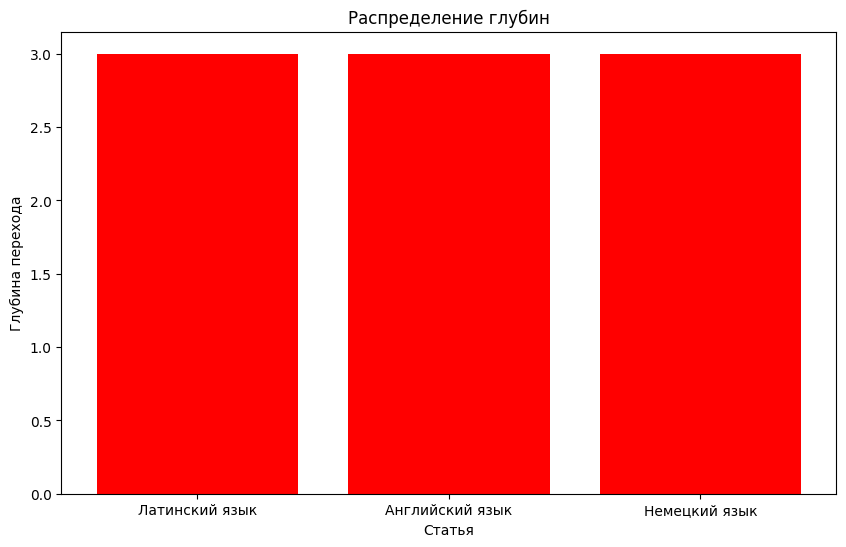

In [10]:
plt.figure(figsize=(10, 6))
plt.xlabel('Статья')
plt.ylabel('Глубина перехода')
plt.title('Распределение глубин')
articles = ['Латинский язык', 'Английский язык', 'Немецкий язык']
values = [Latin, English, German]
plt.bar(articles, values, color='r')
plt.show()